<a href="https://colab.research.google.com/github/CHIRANJEEVBHATT/Machine-learning-/blob/main/AutoPrice_Compass_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AutoPrice Compass — Data Analysis + Regression
**PBL-I Project Review** · Dataset: *Used Car Prices (India)* — Kaggle `sujay1844/used-car-prices` (`train.csv`)

**Problem.** Used-car value depends on age, mileage, fuel type, transmission, ownership and engine attributes. Static rule-based pricing ignores these interactions, so this notebook builds a data-driven pipeline to estimate prices transparently.

**This notebook covers:** Part 2 – Exploratory Data Analysis & Insights, and Part 3 – Regression Implementation (Linear / Least-Squares Regression and Ridge Regression).


In [1]:
import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')

# Consistent palette used across notebooks and the presentation
NAVY, TEAL, AMBER, CORAL, SLATE = '#1F3A5F', '#2A9D8F', '#E9A23B', '#E76F51', '#6B7A8F'
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold', 'axes.spines.top': False, 'axes.spines.right': False})
os.makedirs('figures', exist_ok=True)
RANDOM_STATE = 42

DATA_PATH = 'train.csv' if os.path.exists('train.csv') else '/content/train.csv'
raw = pd.read_csv(DATA_PATH)
print('Raw shape:', raw.shape)
raw.head()

Raw shape: (5847, 14)


,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
1,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13 km/kg,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
2,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,3.50


## 1. Data understanding

In [2]:
raw.info()
print()
print('Duplicate rows (ignoring index column):', raw.duplicated(subset=raw.columns[1:]).sum())
miss = raw.isna().sum().to_frame('missing'); miss['pct'] = (miss.missing / len(raw) * 100).round(1)
miss[miss.missing > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5847 entries, 0 to 5846
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         5847 non-null   int64  
 1   Name               5847 non-null   object 
 2   Location           5847 non-null   object 
 3   Year               5847 non-null   int64  
 4   Kilometers_Driven  5847 non-null   int64  
 5   Fuel_Type          5847 non-null   object 
 6   Transmission       5847 non-null   object 
 7   Owner_Type         5847 non-null   object 
 8   Mileage            5845 non-null   object 
 9   Engine             5811 non-null   object 
 10  Power              5811 non-null   object 
 11  Seats              5809 non-null   float64
 12  New_Price          815 non-null    object 
 13  Price              5847 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 639.6+ KB

Duplicate rows (ignoring index column): 0


,missing,pct
Mileage,2,0.0
Engine,36,0.6
Power,36,0.6
Seats,38,0.6
New_Price,5032,86.1


**Observations.** `Mileage`, `Engine`, `Power` are stored as text with units (kmpl, CC, bhp); `New_Price` is ~86 % missing so it is dropped; `Seats`, `Engine`, `Power` have a few dozen gaps (imputed later inside the model pipeline to avoid leakage).

## 2. Data cleaning & feature engineering

In [3]:
df = raw.drop(columns=['Unnamed: 0', 'New_Price']).copy()

# Numeric extraction from text columns
df['Mileage'] = pd.to_numeric(df['Mileage'].str.extract(r'([\d.]+)')[0], errors='coerce')
df['Engine']  = pd.to_numeric(df['Engine'].str.extract(r'([\d.]+)')[0], errors='coerce')
df['Power']   = pd.to_numeric(df['Power'].str.extract(r'([\d.]+)')[0], errors='coerce')
df.loc[df['Mileage'] == 0, 'Mileage'] = np.nan          # 0 kmpl is a data-entry gap

# Brand from the first word of Name; fix split/duplicate spellings
df['Brand'] = df['Name'].str.split().str[0].replace({'Land': 'Land Rover', 'ISUZU': 'Isuzu'})
# Car age relative to the newest model year in the data
REF_YEAR = df['Year'].max()
df['Age'] = REF_YEAR - df['Year']

# Remove physically implausible odometer readings (> 500,000 km)
before = len(df)
df = df[df['Kilometers_Driven'] <= 500_000].reset_index(drop=True)
print(f'Removed {before-len(df)} extreme-odometer rows -> {len(df)} rows remain')
df = df.drop(columns=['Name', 'Year'])
df.head()

Removed 4 extreme-odometer rows -> 5843 rows remain


,Location,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Age
0,Pune,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50,Hyundai,4
1,Chennai,46000,Petrol,Manual,First,13.00,1199.0,88.70,5.0,4.50,Honda,8
2,Chennai,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00,Maruti,7
3,Coimbatore,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74,Audi,6
4,Jaipur,86999,Diesel,Manual,First,23.08,1461.0,63.10,5.0,3.50,Nissan,6


## 3. Exploratory Data Analysis

### 3.1 Summary statistics

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Kilometers_Driven,5843.0,56975.71,34903.75,171.00,33437.50,52516.00,72457.50,480000.0
Mileage,5801.0,18.28,4.10,6.40,15.29,18.20,21.10,28.4
Engine,5807.0,1631.34,601.87,72.00,1198.00,1497.00,1991.00,5998.0
Power,5807.0,113.78,53.88,34.20,78.00,98.60,138.56,560.0
Seats,5805.0,5.29,0.81,2.00,5.00,5.00,5.00,10.0
Price,5843.0,9.65,11.26,0.44,3.55,5.75,10.25,160.0
Age,5843.0,5.55,3.20,0.00,3.00,5.00,7.00,21.0


### 3.2 Target variable — Price (₹ Lakh)

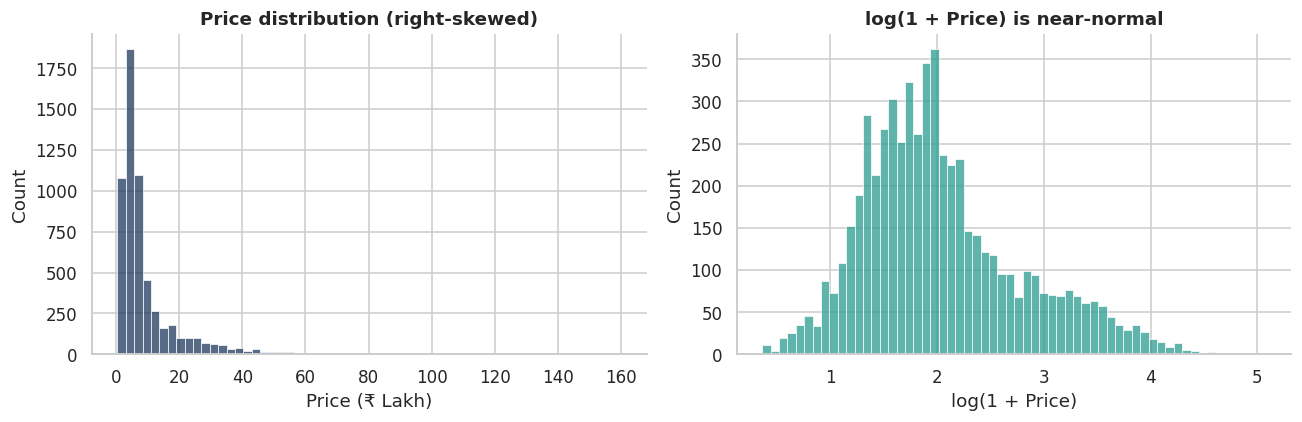

Skewness  raw: 3.31 | log: 0.75
Median price: 5.75 Lakh | Mean: 9.65 Lakh


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Price'], bins=60, color=NAVY, ax=ax[0]); ax[0].set_title('Price distribution (right-skewed)'); ax[0].set_xlabel('Price (₹ Lakh)')
sns.histplot(np.log1p(df['Price']), bins=60, color=TEAL, ax=ax[1]); ax[1].set_title('log(1 + Price) is near-normal'); ax[1].set_xlabel('log(1 + Price)')
plt.tight_layout(); plt.savefig('figures/eda_price_dist.png', dpi=160, bbox_inches='tight'); plt.show()
print('Skewness  raw: %.2f | log: %.2f' % (df['Price'].skew(), np.log1p(df['Price']).skew()))
print('Median price: %.2f Lakh | Mean: %.2f Lakh' % (df['Price'].median(), df['Price'].mean()))

**Insight.** Price is strongly right-skewed (a few luxury cars cost 50–160 Lakh). A log transform removes most of the skew, which suits linear models whose residuals are assumed roughly Gaussian.

### 3.3 Age and usage vs price

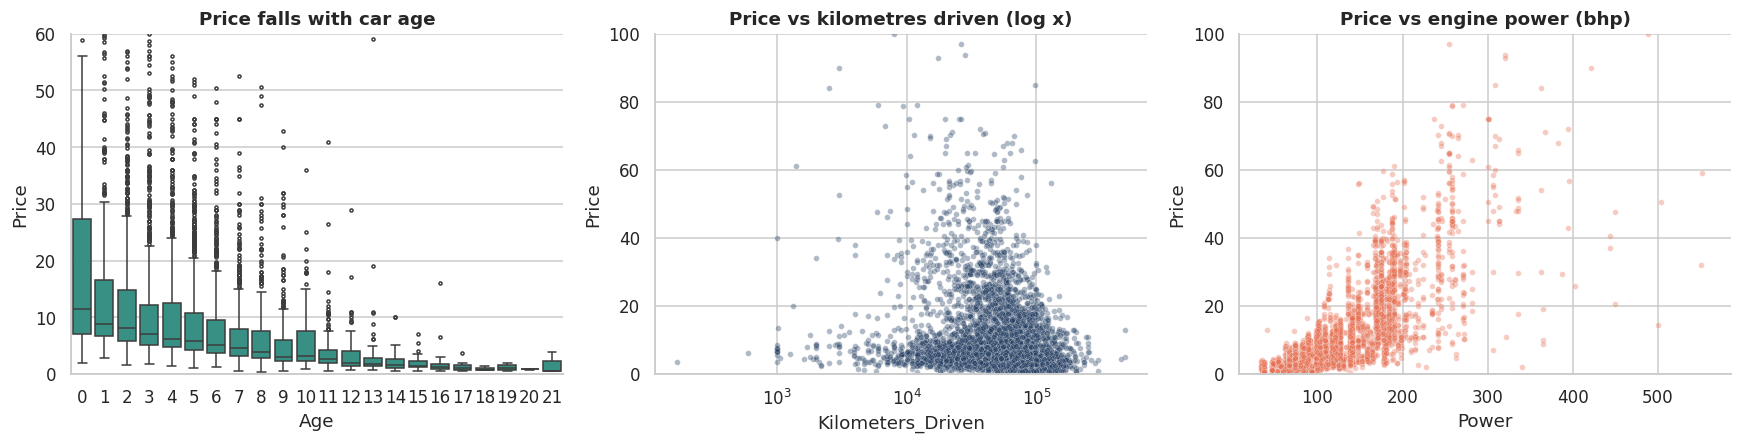

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
sns.boxplot(data=df, x='Age', y='Price', color=TEAL, fliersize=2, ax=ax[0]); ax[0].set_title('Price falls with car age'); ax[0].set_ylim(0, 60)
sns.scatterplot(data=df, x='Kilometers_Driven', y='Price', alpha=.35, s=14, color=NAVY, ax=ax[1]); ax[1].set_xscale('log'); ax[1].set_title('Price vs kilometres driven (log x)'); ax[1].set_ylim(0, 100)
sns.scatterplot(data=df, x='Power', y='Price', alpha=.35, s=14, color=CORAL, ax=ax[2]); ax[2].set_title('Price vs engine power (bhp)'); ax[2].set_ylim(0, 100)
plt.tight_layout(); plt.savefig('figures/eda_age_km_power.png', dpi=160, bbox_inches='tight'); plt.show()

**Insight.** Median price drops steadily with age; very high-mileage cars cluster at low prices; power shows a clear positive relationship with price (premium/performance cars).

### 3.4 Categorical drivers

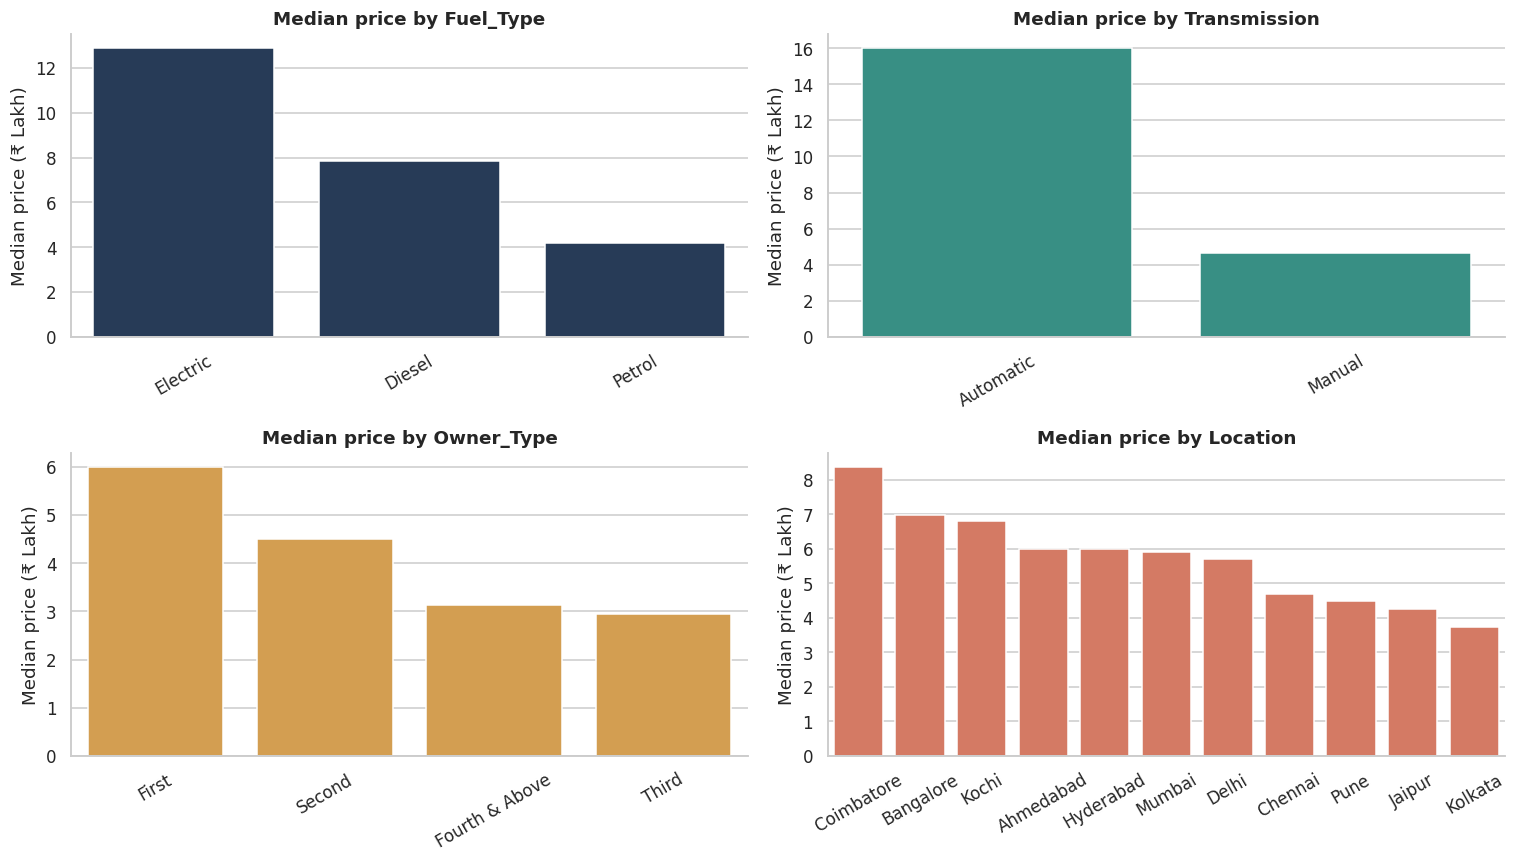

{'Automatic': 16.0, 'Manual': 4.65}


In [7]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
for a, col, c in zip(ax.ravel(), ['Fuel_Type', 'Transmission', 'Owner_Type', 'Location'], [NAVY, TEAL, AMBER, CORAL]):
    order = df.groupby(col)['Price'].median().sort_values(ascending=False).index
    sns.barplot(data=df, x=col, y='Price', order=order, estimator=np.median, errorbar=None, color=c, ax=a)
    a.set_title(f'Median price by {col}'); a.set_ylabel('Median price (₹ Lakh)'); a.set_xlabel('')
    a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig('figures/eda_categorical.png', dpi=160, bbox_inches='tight'); plt.show()
print(df.groupby('Transmission')['Price'].median().round(2).to_dict())

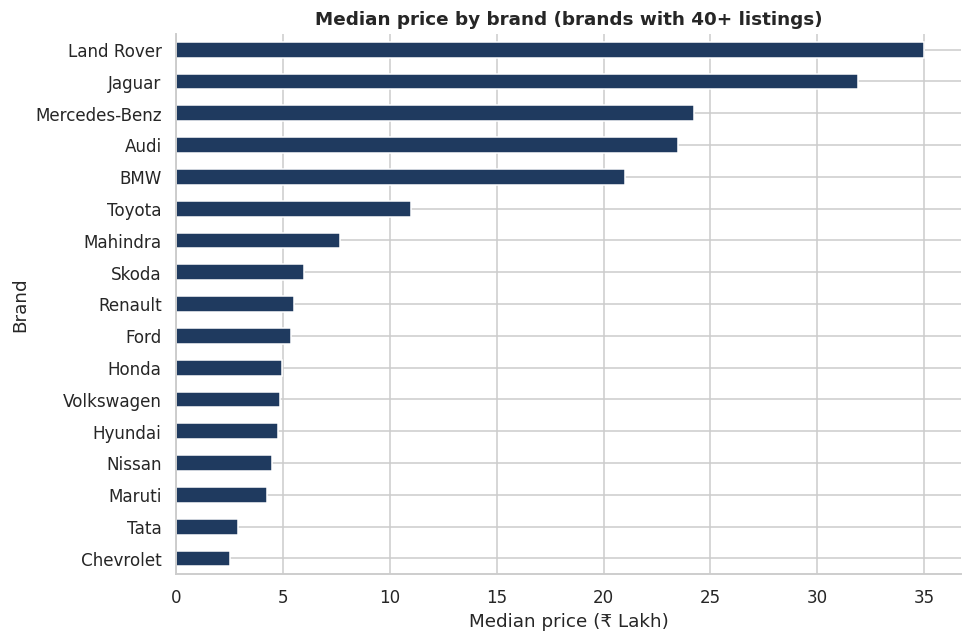

In [8]:
top = df['Brand'].value_counts().loc[lambda s: s >= 40].index
bp = df[df['Brand'].isin(top)].groupby('Brand')['Price'].median().sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
bp.plot.barh(color=NAVY, ax=ax); ax.set_title('Median price by brand (brands with 40+ listings)'); ax.set_xlabel('Median price (₹ Lakh)')
plt.tight_layout(); plt.savefig('figures/eda_brand.png', dpi=160, bbox_inches='tight'); plt.show()

**Insight.** Automatic cars, diesel cars, first-owner cars and premium brands (Land Rover, Mercedes-Benz, BMW, Audi, Jaguar) command higher prices; location effects are smaller but visible (e.g., Coimbatore and Bangalore vs Kolkata/Jaipur).

### 3.5 Correlation structure

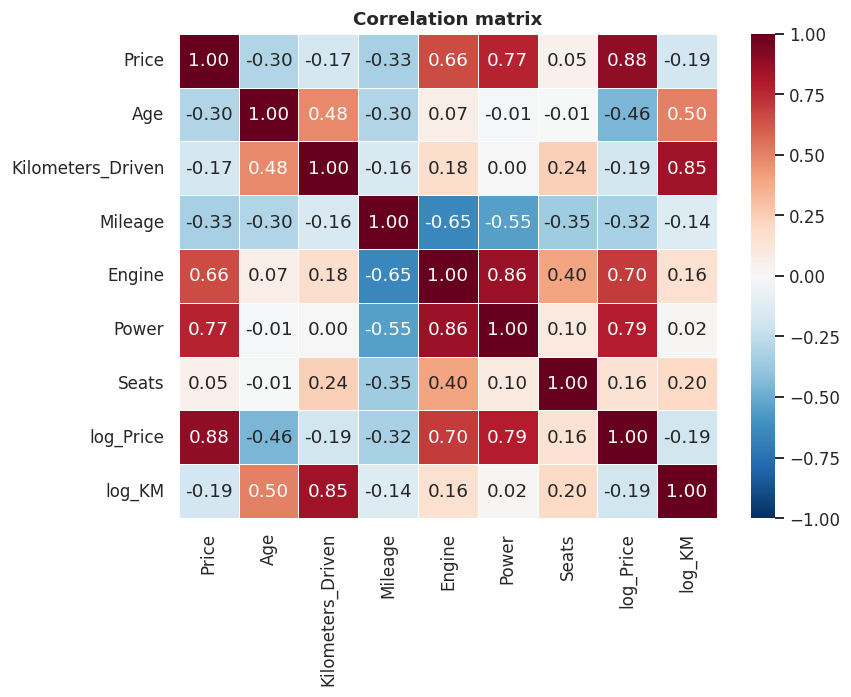

,Price
Power,0.772
Engine,0.656
Seats,0.054
Kilometers_Driven,-0.175
log_KM,-0.186
Age,-0.300
Mileage,-0.334


In [9]:
num = df[['Price', 'Age', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']].copy()
num['log_Price'] = np.log1p(num['Price']); num['log_KM'] = np.log1p(num['Kilometers_Driven'])
corr = num.corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=.5, ax=ax)
ax.set_title('Correlation matrix'); plt.tight_layout(); plt.savefig('figures/eda_corr.png', dpi=160, bbox_inches='tight'); plt.show()
corr['Price'].drop(['Price', 'log_Price']).sort_values(ascending=False).round(3)

**Insight.** Power and engine size are the strongest positive correlates of price, age the strongest negative; `Power` and `Engine` are highly collinear (~0.86), which motivates **Ridge** regularisation in the regression experiments.

### 3.6 Missing values after cleaning

In [10]:
m = df.isna().sum(); print(m[m > 0].to_string())
print('\nCleaned shape:', df.shape)

Mileage    42
Engine     36
Power      36
Seats      38

Cleaned shape: (5843, 12)


In [11]:
# Shared model feature definitions
NUM_FEATURES = ['Age', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']
CAT_FEATURES = ['Brand', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type']

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split

def make_preprocessor():
    # log-transform the heavily skewed odometer, then impute (median) and standardise
    num_pipe = Pipeline([('impute', SimpleImputer(strategy='median')),
                         ('scale', StandardScaler())])
    cat_pipe = Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                         ('ohe', OneHotEncoder(handle_unknown='ignore'))])
    return ColumnTransformer([('num', num_pipe, NUM_FEATURES), ('cat', cat_pipe, CAT_FEATURES)])

X = df[NUM_FEATURES + CAT_FEATURES].copy()
X['Kilometers_Driven'] = np.log1p(X['Kilometers_Driven'])   # tame the long right tail
print('Feature matrix:', X.shape)

Feature matrix: (5843, 11)


## 4. Regression implementation
**Goal:** predict the continuous used-car price (₹ Lakh).

| Model | Syllabus link (Unit-2) |
|---|---|
| **Linear Regression (ordinary least squares)** | Maximum-likelihood estimation under Gaussian noise ⇒ least squares |
| **Ridge Regression (L2)** | Regularised least squares = MAP estimate with a Gaussian prior on weights (Bayesian view); handles collinearity |

Target = `log(1 + Price)` (fixes skew); metrics are reported back on the original ₹ Lakh scale. 80/20 train–test split.

In [12]:
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y = df['Price'].values
y_log = np.log1p(y)
X_tr, X_te, ylog_tr, ylog_te, y_tr, y_te = train_test_split(X, y_log, y, test_size=0.2, random_state=RANDOM_STATE)
print('Train:', X_tr.shape, '| Test:', X_te.shape)

Train: (4674, 11) | Test: (1169, 11)


### 4.1 Model A — Linear Regression (Ordinary Least Squares)

In [13]:
ols = Pipeline([('prep', make_preprocessor()), ('model', LinearRegression())]).fit(X_tr, ylog_tr)
pred_ols = np.expm1(ols.predict(X_te))

### 4.2 Model B — Ridge Regression (α tuned by cross-validation)

Best alpha: 0.788


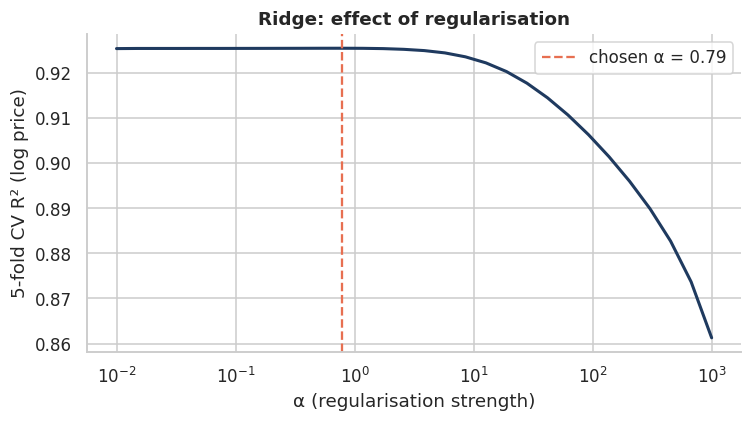

In [14]:
alphas = np.logspace(-2, 3, 30)
ridge_cv = Pipeline([('prep', make_preprocessor()), ('model', RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error'))]).fit(X_tr, ylog_tr)
best_alpha = ridge_cv.named_steps['model'].alpha_
print('Best alpha:', round(best_alpha, 3))
ridge = Pipeline([('prep', make_preprocessor()), ('model', Ridge(alpha=best_alpha))]).fit(X_tr, ylog_tr)
pred_ridge = np.expm1(ridge.predict(X_te))

# Validation curve: how test/CV error varies with alpha
cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)
scores = [cross_val_score(Pipeline([('prep', make_preprocessor()), ('model', Ridge(alpha=a))]), X_tr, ylog_tr, cv=cv, scoring='r2').mean() for a in alphas]
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(alphas, scores, color=NAVY, lw=2); ax.axvline(best_alpha, color=CORAL, ls='--', label=f'chosen α = {best_alpha:.2f}')
ax.set_xlabel('α (regularisation strength)'); ax.set_ylabel('5-fold CV R² (log price)'); ax.set_title('Ridge: effect of regularisation'); ax.legend()
plt.tight_layout(); plt.savefig('figures/reg_ridge_alpha.png', dpi=160, bbox_inches='tight'); plt.show()

### 4.3 Evaluation

In [15]:
def evaluate(name, pipe, pred, ylog_pred_fn):
    cvr2 = cross_val_score(pipe, X_tr, ylog_tr, cv=cv, scoring='r2').mean()
    return {'Model': name,
            'R2 (₹ scale)': r2_score(y_te, pred),
            'R2 (log scale)': r2_score(ylog_te, np.log1p(pred)),
            'RMSE (Lakh)': mean_squared_error(y_te, pred) ** 0.5,
            'MAE (Lakh)': mean_absolute_error(y_te, pred),
            'MAPE (%)': float(np.mean(np.abs(y_te - pred) / y_te) * 100),
            'CV R2 (log, 5-fold)': cvr2}

res = pd.DataFrame([evaluate('Linear Regression (OLS)', Pipeline([('prep', make_preprocessor()), ('model', LinearRegression())]), pred_ols, None),
                    evaluate('Ridge Regression', Pipeline([('prep', make_preprocessor()), ('model', Ridge(alpha=best_alpha))]), pred_ridge, None)]).set_index('Model')
res.round(4)

,R2 (₹ scale),R2 (log scale),RMSE (Lakh),MAE (Lakh),MAPE (%),"CV R2 (log, 5-fold)"
Model,,,,,,
Linear Regression (OLS),0.8135,0.9205,5.0123,1.9626,19.4317,0.9254
Ridge Regression,0.8105,0.9199,5.0528,1.9695,19.4561,0.9254


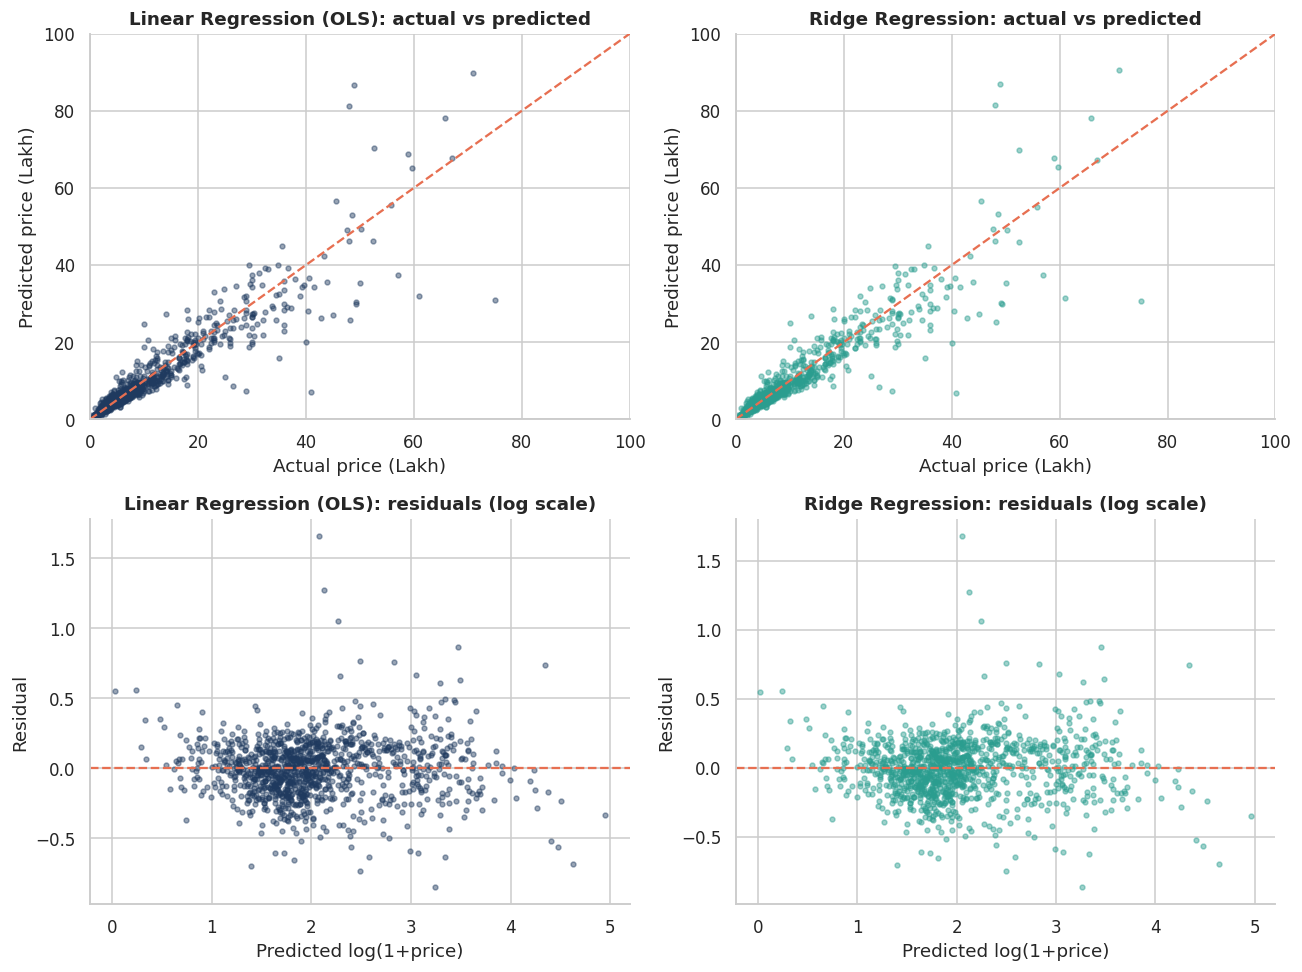

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
for j, (nm, p, c) in enumerate([('Linear Regression (OLS)', pred_ols, NAVY), ('Ridge Regression', pred_ridge, TEAL)]):
    ax[0, j].scatter(y_te, p, s=10, alpha=.45, color=c); lim = [0, max(y_te.max(), p.max())]
    ax[0, j].plot(lim, lim, color=CORAL, ls='--'); ax[0, j].set_xlim(0, 100); ax[0, j].set_ylim(0, 100)
    ax[0, j].set_title(f'{nm}: actual vs predicted'); ax[0, j].set_xlabel('Actual price (Lakh)'); ax[0, j].set_ylabel('Predicted price (Lakh)')
    resid = np.log1p(y_te) - np.log1p(p)
    ax[1, j].scatter(np.log1p(p), resid, s=10, alpha=.45, color=c); ax[1, j].axhline(0, color=CORAL, ls='--')
    ax[1, j].set_title(f'{nm}: residuals (log scale)'); ax[1, j].set_xlabel('Predicted log(1+price)'); ax[1, j].set_ylabel('Residual')
plt.tight_layout(); plt.savefig('figures/reg_actual_vs_pred.png', dpi=160, bbox_inches='tight'); plt.show()

### 4.4 What drives the price? (Ridge coefficients)

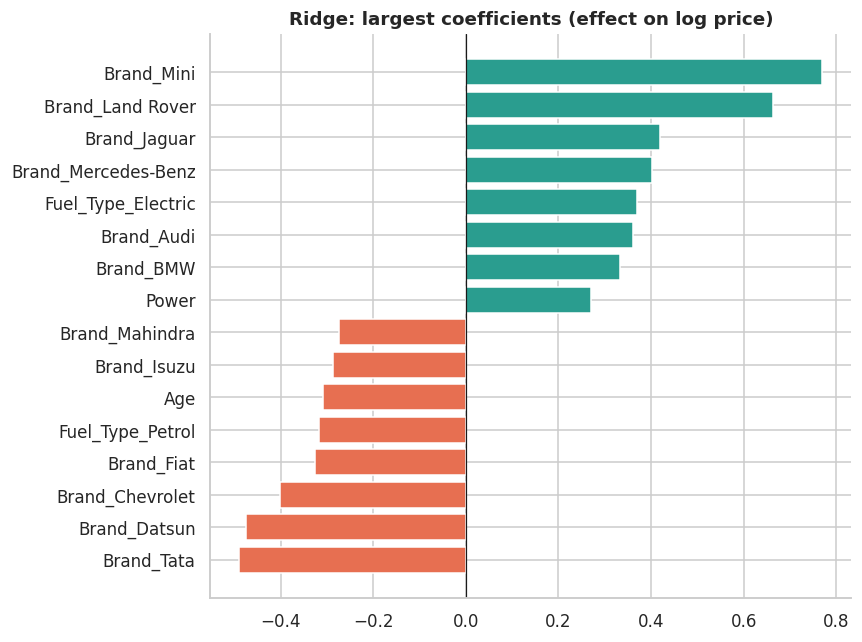

In [17]:
prep = ridge.named_steps['prep']; names = prep.get_feature_names_out()
coef = pd.Series(ridge.named_steps['model'].coef_, index=[n.split('__')[1] for n in names]).sort_values()
top = pd.concat([coef.head(8), coef.tail(8)])
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index, top.values, color=[CORAL if v < 0 else TEAL for v in top.values]); ax.axvline(0, color='k', lw=.8)
ax.set_title('Ridge: largest coefficients (effect on log price)'); plt.tight_layout(); plt.savefig('figures/reg_coef.png', dpi=160, bbox_inches='tight'); plt.show()

In [18]:
results = res.reset_index().to_dict(orient='records')
out = {'task': 'regression', 'n_train': int(len(X_tr)), 'n_test': int(len(X_te)), 'best_alpha': float(best_alpha), 'results': results,
       'top_positive': coef.tail(5).round(3).to_dict(), 'top_negative': coef.head(5).round(3).to_dict(),
       'eda': {'rows': int(len(df)), 'median_price': float(df.Price.median()), 'mean_price': float(df.Price.mean()),
               'skew_raw': float(df.Price.skew()), 'skew_log': float(np.log1p(df.Price).skew()),
               'corr_with_price': corr['Price'].drop(['Price', 'log_Price']).round(3).to_dict(),
               'median_by_fuel': df.groupby('Fuel_Type')['Price'].median().round(2).to_dict(),
               'median_by_trans': df.groupby('Transmission')['Price'].median().round(2).to_dict(),
               'median_by_owner': df.groupby('Owner_Type')['Price'].median().round(2).to_dict(),
               'median_by_brand_top': bp.round(2).to_dict()}}
json.dump(out, open('results_regression.json', 'w'), indent=2, default=float)
print('Saved results_regression.json')

Saved results_regression.json


## 5. Interpretation
* Both models explain a large share of price variance on the log scale; log-transforming the target is what makes a *linear* model competitive here.
* Ridge and OLS perform almost identically because the dataset is large relative to the number of features, so over-fitting is mild — the regularisation mainly **stabilises coefficients** for correlated inputs (Power/Engine, brand dummies).
* In absolute terms the error grows with price (test MAE ≈ ₹0.6 Lakh for cars under 4.25 Lakh vs ≈ ₹8 Lakh for cars above 20 Lakh), while the *relative* error stays roughly 15–23 % in every price band — luxury cars are simply harder to price to the rupee. A purely linear structure is a limitation here, motivating non-linear/kernel models in future work.